# Дообучение диффузионной модели

Проект по дообучению диффузионной модели для визуализации неизвестным объектам (на прмере чебурашки)

Проведём необходимые импорты, укажем пути, зафиксируем сиды и определим девайс.

In [1]:
import os
import gc

from diffusers import StableDiffusionPipeline, DDPMScheduler, AutoencoderKL, UNet2DConditionModel
from diffusers.optimization import get_scheduler
from peft import LoraConfig, PeftModel, get_peft_model_state_dict

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from tqdm import tqdm

from utilits import Visualisator, CheburashkaDataset, save_checkpoint, draw_loss_graph
import numpy as np

W0403 20:13:50.174000 8396 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [2]:
PATH_TO_IMAGES = 'data'
PATH_TO_ARTIFACTS = 'artifacts'

In [3]:
torch.manual_seed(42)
np.random.seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

## Работа с данными и демонстрация работы сырой модели

Визуализируем картинки для обучения, чтобы показать как должен выглядеть чебурашка.

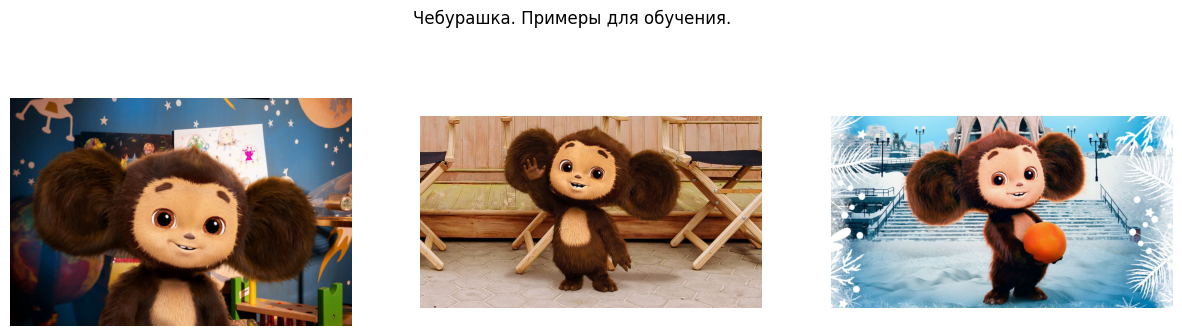

In [4]:
viz = Visualisator(PATH_TO_IMAGES, PATH_TO_ARTIFACTS)
viz.visualize('Чебурашка. Примеры для обучения.', 'cheburashka_for_train.png')

Посмотрим, на что способна сырая модель. В качестве модели будем испльзовать runwayml/stable-diffusion-v1-5

In [5]:
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)
pipe = pipe.to(device)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Сгенерируем 3 примера на основании промпта.

In [ ]:
prompt = "<cheburashka> with the Eiffel Tower in the background"
negative_prompt = "low quality, blurry"

folder_to_save = os.path.join(PATH_TO_ARTIFACTS, 'before_train')
os.makedirs(folder_to_save, exist_ok=True)
for i in range(3):
    image = pipe(
        prompt, 
        negative_prompt=negative_prompt,
        num_inference_steps=30,
        height=1024,
        width=1024,
        guidance_scale=7.5
    ).images[0]

    path_to_save = os.path.join(folder_to_save, f'cheburashka_raw_{i}.png')
    image.save(path_to_save)

    del image
    gc.collect()
    torch.cuda.empty_cache() 
    torch.cuda.synchronize()

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Визуализируем их.

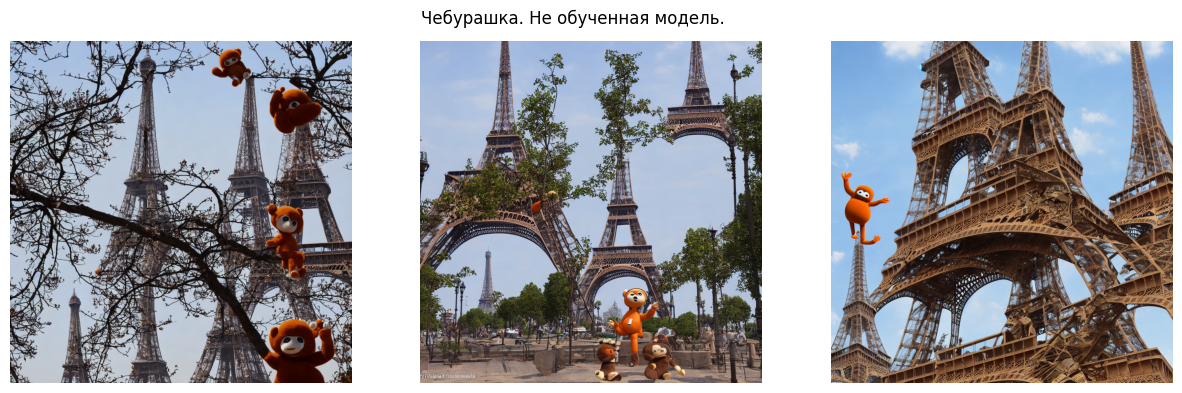

In [7]:
viz = Visualisator(folder_to_save, PATH_TO_ARTIFACTS)
viz.visualize('Чебурашка. Не обученная модель.', 'cheburashka_raw_model.png')

Как видим, модель не справилась с задачей и не понимает, что такое чебурашка.

Закодируем текст "\<cheburashka\> plushie" с помощью функции encode_prompt 

In [8]:
prompt_text = "<cheburashka> plushie"

with torch.no_grad():
    prompt_embeds, negative_prompt_embeds = pipe.encode_prompt(
        prompt=prompt_text,
        device="cuda",
        num_images_per_prompt=1,
        do_classifier_free_guidance=True,
    )

Сохраним полученные эмбединги.

In [9]:
torch.save({
    "prompt_embeds": prompt_embeds.cpu(),
    "negative_prompt_embeds": negative_prompt_embeds.cpu()
}, "embeddings/cheburashka_plushie_embeddings.pt")

Удаляем пайплайн, чистим память

In [ ]:
del pipe
gc.collect()
torch.cuda.empty_cache() 
torch.cuda.synchronize()

## Дообучение модели

Загрузим модель и настроим LoRA

In [11]:
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float32
).to(device)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [12]:
lora_config = LoraConfig(
    r=128, 
    target_modules=["to_k", "to_q", "to_v", "to_out.0"], 
    init_lora_weights="gaussian",
    lora_dropout=0.1
)

Объединение LoRa и основной модели. Заморозка весов. Перевод в режим тренировки.

In [13]:
pipe.unet.add_adapter(lora_config)

pipe.vae.requires_grad_(False)
pipe.text_encoder.requires_grad_(False)

for param in pipe.unet.parameters():
    param.requires_grad = False

for name, param in pipe.unet.named_parameters():
    if "lora" in name.lower():
        param.requires_grad = True

pipe.unet.train()

UNet2DConditionModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=320, out_features=1280, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=1280, out_features=1280, bias=True)
  )
  (down_blocks): ModuleList(
    (0): CrossAttnDownBlock2D(
      (attentions): ModuleList(
        (0-1): 2 x Transformer2DModel(
          (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (proj_in): Conv2d(320, 320, kernel_size=(1, 1), stride=(1, 1))
          (transformer_blocks): ModuleList(
            (0): BasicTransformerBlock(
              (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
              (attn1): Attention(
                (to_q): lora.Linear(
                  (base_layer): Linear(in_features=320, out_features=320, bias=False)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=

Создадим датасет и даталоадер.

In [14]:
files = os.listdir(PATH_TO_IMAGES)
image_paths = [
    os.path.join(PATH_TO_IMAGES, img) 
    for img in files 
    if os.path.splitext(img)[1] in ['.png', '.jpg']
]

dataset = CheburashkaDataset(image_paths, size=512)
train_dataloader = DataLoader(
    dataset, 
    batch_size=1,
    shuffle=True
)

Загрузим полученные ранее эмбединги

In [15]:
embeddings_data = torch.load("embeddings/cheburashka_plushie_embeddings.pt")
prompt_embeds = embeddings_data["prompt_embeds"].to("cuda", dtype=torch.float32)
negative_prompt_embeds = embeddings_data["negative_prompt_embeds"].to("cuda", dtype=torch.float32)

Настроим оптимизатор, планировщик скорости обучения и планировщик диффузии.

In [16]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, pipe.unet.parameters()),
    lr=2.0e-05,
    weight_decay=1e-2,
    eps=1e-08
)

In [17]:
lr_scheduler = get_scheduler(
    "constant",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=1000
)

In [18]:
noise_scheduler = DDPMScheduler.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    subfolder="scheduler"
)

In [19]:
scaler = torch.cuda.amp.GradScaler()

C:\Users\yaros\AppData\Local\Temp\ipykernel_10588\2340218076.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Помещаем VAE и текстовый энкодор на ГПУ, переводим их в режим оценки, т.к. они не учатся.

In [20]:
pipe.vae = pipe.vae.to("cuda")
pipe.text_encoder = pipe.text_encoder.to("cuda")
pipe.vae.eval()
pipe.text_encoder.eval()

CLIPTextModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 768)
      (position_embedding): Embedding(77, 768)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e

Задаём параметры обучения и создаём прогремм бар для визуализации

In [21]:
max_train_steps = 1000
snr_gamma = 5.0
losses = []

In [22]:
progress_bar = tqdm(range(max_train_steps), desc="Обучение")
global_step = 0

Обучение:   0%|          | 0/1000 [00:00<?, ?it/s]

Цикл обучения.

In [23]:
while global_step < max_train_steps:
    for batch in train_dataloader:
        # VAE 
        # Кодирует изображения в латентное пространство меньшей размерности.
        # Это ускоряет обучение и уменьшает потребление памяти.
        with torch.no_grad():
            latents = pipe.vae.encode(batch.to("cuda")).latent_dist.sample()
            latents = latents * pipe.vae.config.scaling_factor
        
        # Семплирование диффузионного времени
        # Случайно выбираем время t из равномерного распределения [0, 1), 
        # для опредления уровеня зашумленности (0 - чистое изображение, 1 - чистый шум)
        timesteps = torch.randint(
            0, noise_scheduler.config.num_train_timesteps, 
            (latents.shape[0],), device=latents.device
        ).long()
        
        # Зашумление изображения
        noise = torch.randn_like(latents)
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)
        
        # Подготовка входных данных для основной модели (UNet)
        # На вход UNet подаются:
        # - зашумленные латенты
        # - время диффузии
        # - текстовые эмбеддинги
        batch_size = latents.shape[0]
        encoder_hidden_states = prompt_embeds.repeat(batch_size, 1, 1)

        # Прямой проход
        # Модель предсказывает шум, который был добавлен ранее
        noise_pred = pipe.unet(
            noisy_latents, timesteps, encoder_hidden_states
        ).sample

        # Расчет функции потерь     
        if snr_gamma is not None:
            # Вычисляем SNR 
            alphas_cumprod = noise_scheduler.alphas_cumprod.to(latents.device)
            snr = alphas_cumprod[timesteps] / (1 - alphas_cumprod[timesteps])
            # Вычисляем веса для каждого примера
            snr_weight = torch.where(snr < snr_gamma, snr, torch.ones_like(snr) * snr_gamma)
            snr_weight = snr_weight / snr_gamma
            # Взвешенный MSE loss
            loss = F.mse_loss(noise_pred, noise, reduction="none")
            loss = loss.mean(dim=list(range(1, len(loss.shape)))) * snr_weight
            loss = loss.mean()
        else:
            loss = F.mse_loss(noise_pred, noise, reduction="mean")
                
        # Обратное распространение
        loss.backward()
        torch.nn.utils.clip_grad_norm_(pipe.unet.parameters(), 1)
        
        optimizer.step()
        optimizer.zero_grad()
        
        losses.append(loss.detach().item())
        progress_bar.update(1)
        progress_bar.set_postfix({"loss": losses[-1], "step": global_step})
        
        # Сохраняем чекпоинты
        if (global_step + 1) % 500 == 0:
            save_checkpoint(
                pipe, 
                optimizer, 
                global_step + 1
            )
        
        global_step += 1
        
        # выходим из ципкла, если достигнутое заданое количество шагов
        if global_step >= max_train_steps:
            break

progress_bar.close()

Обучение:  50%|█████     | 500/1000 [04:07<04:01,  2.07it/s, loss=1.47e-5, step=499] 

Чекпоинт сохранен: checkpoints\checkpoint_step_500


Обучение: 100%|██████████| 1000/1000 [08:54<00:00,  1.87it/s, loss=6.18e-6, step=999]

Чекпоинт сохранен: checkpoints\checkpoint_step_1000


Сохраним финальную модель с метаинформацией.

In [28]:
final_save_path = "models/cheburashka_lora_final"
os.makedirs(final_save_path, exist_ok=True)

lora_state_dict = get_peft_model_state_dict(pipe.unet)
pipe.save_lora_weights(
    save_directory=final_save_path,
    unet_lora_layers=lora_state_dict,
    safe_serialization=True # Сохранит в современном формате .safetensors
)

config = {
    "lora_rank": 128,
    "trained_steps": max_train_steps,
    "learning_rate": 2.0e-05,
}
torch.save(config, os.path.join(final_save_path, "training_config.pt"))

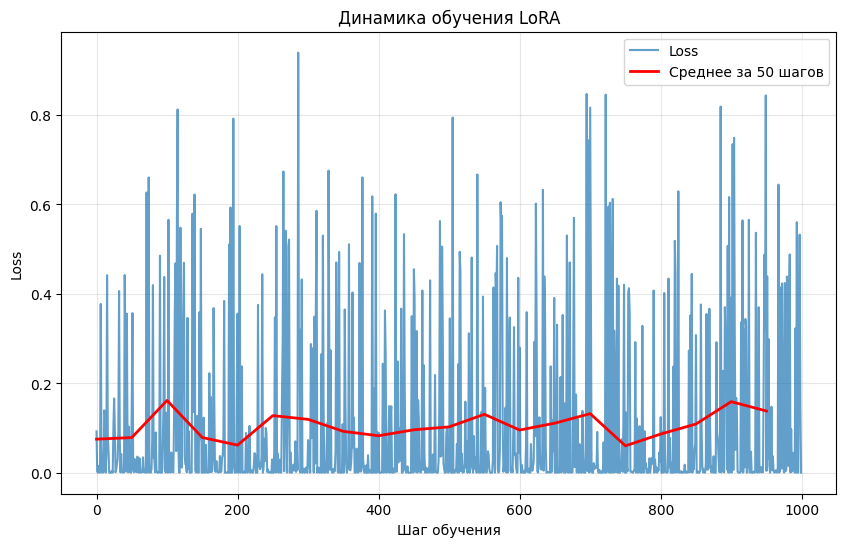

In [29]:
draw_loss_graph(losses, os.path.join(PATH_TO_ARTIFACTS, 'loss.png'))

Высвобождаем ресурсы

In [30]:
del pipe 
del optimizer, lr_scheduler, noise_scheduler
del batch, latents, noisy_latents, noise, noise_pred, encoder_hidden_states, timesteps
del train_dataloader
del progress_bar

gc.collect()
torch.cuda.empty_cache() 
torch.cuda.synchronize()

## Демонстрация результатов

Создадим снова пайплайн генерации и загрузим обученную модель.

In [5]:
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float32
).to("cuda")

pipe.load_lora_weights(final_save_path)

pipe.safety_checker = None
pipe.requires_safety_checker = False

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/30 [00:00<?, ?it/s]

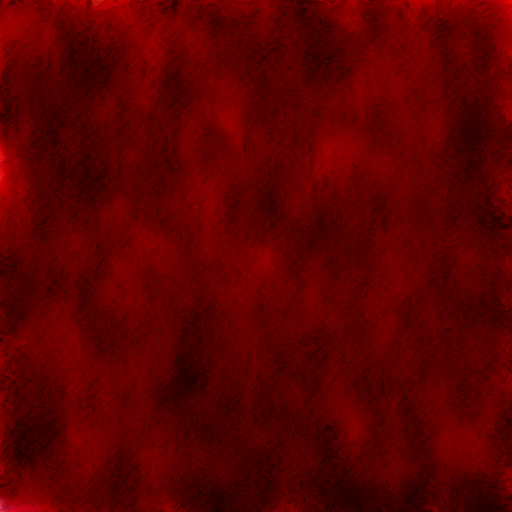

In [11]:
prompt = "<cheburashka> plushie"
negative_prompt = "low quality, blurry"
with torch.no_grad():
    image = pipe(
        prompt, 
        negative_prompt=negative_prompt,
        num_inference_steps=30,
        height=512,
        width=512,
        guidance_scale=7.5
    ).images[0]
image

In [10]:
del image
gc.collect()
torch.cuda.empty_cache() 
torch.cuda.synchronize()

In [ ]:
prompts = [
    "<cheburashka> with the Eiffel Tower in the background",
    "<cheburashka> plushie",
    "<cheburashka> in sketch style",
    "<cheburashka> riding a bicycle"
]

In [ ]:
negative_prompt = "low quality, blurry"

for i, prompt in enumerate(prompts):
    folder_to_save = os.path.join(PATH_TO_ARTIFACTS, 'after_train', f'prompt_{i}')
    os.makedirs(folder_to_save, exist_ok=True)
    for n in range(3):
        image = pipe(
            prompt, 
            negative_prompt=negative_prompt,
            num_inference_steps=30,
            height=1024,
            width=1024,
            guidance_scale=7.5
        ).images[0]

        path_to_save = os.path.join(folder_to_save, f'cheburashka_{n}.png')
        image.save(path_to_save)

        del image
        gc.collect()
        torch.cuda.empty_cache() 
        torch.cuda.synchronize()

  0%|          | 0/30 [00:00<?, ?it/s]